# 4. Three-dimensional integral boundary layer

Notebook 2 ended with a specific diagnosis. The quasi-3D strip march predicts
lateral damping of the right sign but roughly a fifth of the required
magnitude, and the missing mechanism is **crossflow**: the strip march
advances a single scalar momentum thickness using $|\boldsymbol u_e|$, so it
has no equation for momentum transported *across* the external streamlines
and no way to develop a wall shear that is skewed away from them.

This notebook records the crossflow-capable replacement — what it is, what it
reproduces, and where it currently fails. It also settles a separate question
raised by notebook 2: whether the Schmitz stern cut is really a separation
cut. It is not, and that turns out to be the same story.

**Read notebooks 1 and 2 first.**

In [1]:
using Pkg

function marinehydro_root(start = pwd())
    directory = abspath(start)
    while true
        project = joinpath(directory, "Project.toml")
        if isfile(project) && occursin("name = \"MarineHydro\"", read(project, String))
            return directory
        end
        parent = dirname(directory)
        parent == directory && error("Run Jupyter from the MarineHydro.jl repository.")
        directory = parent
    end
end

project_root = marinehydro_root()
Pkg.activate(project_root)

using Revise
using MarineHydro
using CairoMakie
using LinearAlgebra: norm, dot
CairoMakie.activate!()

results_directory = joinpath(project_root, "validation", "gothenburg2010", "results")
mkpath(results_directory)

data_directory = joinpath(project_root, "validation", "gothenburg2010", "data", "KVLCC2")
surface_paths = [joinpath(data_directory, "kvlcc_bow1.dat"),
    joinpath(data_directory, "kvlcc2_stn1.dat")]
all(isfile, surface_paths) ||
    error("Run validation/gothenburg2010/fetch_geometry.sh first.")

REYNOLDS_NUMBER = 4.6e6
FROUDE_NUMBER = 0.142
WATER_DENSITY = 1025.0
forward_speed = FROUDE_NUMBER * sqrt(SETTINGS.g)
kinematic_viscosity = forward_speed / REYNOLDS_NUMBER
ittc_1957 = 0.075 / (log10(REYNOLDS_NUMBER) - 2)^2
(; forward_speed, kinematic_viscosity, ittc_1957)

  Activating project at `c:\Users\iamje\.julia\dev\MarineHydro`


(forward_speed = 0.4447570572795894, kinematic_viscosity = 9.668631679991075e-8, ittc_1957 = 0.0034496540429658747)

## 4.1 What changes

The quasi-3D model carries one scalar $\theta$ per panel. The
three-dimensional model carries the full **momentum-loss tensor**
$\theta_{ij}$, and solves two momentum equations plus a kinetic energy
equation in a local Cartesian surface basis:

$$\frac{\partial\theta_{xx}}{\partial x}+\frac{\partial\theta_{xy}}{\partial y}+g_x=0,
\quad
\frac{\partial\theta_{yx}}{\partial x}+\frac{\partial\theta_{yy}}{\partial y}+g_y=0,
\quad
\frac{\partial\theta^*_x}{\partial x}+\frac{\partial\theta^*_y}{\partial y}+g_e=0.$$

Everything three-dimensional follows from a single closure quantity, Mughal's
crossflow parameter

$$A_c = e^{1-H_k}\,\beta_w,$$

where $\beta_w$ is the wall crossflow angle — the angle between the wall shear
and the external streamline. The crossflow thicknesses are all proportional to
it:

$$\delta^*_2=-A_c\delta^*_1,\quad \theta_{21}=-A_c\theta_{11},\quad
\theta_{12}=\theta_{21}-\delta^*_2,\quad \theta_{22}=-A_c\theta_{12},$$

so at $\beta_w=0$ the entire tensor collapses to the two-dimensional scalar
case. That collapse is the first thing to verify.

| | quasi-3D (`solve_quasi3d_boundary_layer`) | 3D (`solve_three_dimensional_boundary_layer`) |
|---|---|---|
| State per panel | $\theta$, $H$ | $\theta_{11}$, $H_k$, $\beta_w$, $C_\tau$ |
| Equations | momentum + Head entrainment | 2 momentum + kinetic energy + shear lag |
| Shape factor from | entrainment correlation | energy balance |
| Crossflow | none | $\beta_w$ solved |
| Wall shear direction | along $\boldsymbol u_e$ | skewed by $\beta_w$ |
| Closures | Head, Ludwieg–Tillmann | Drela incompressible turbulent |

The scalar closures are Drela's, not Head's. Two relations in Lokatt and
Eller's appendix could not be reconciled with the quantities they are said to
relate, so rather than guess, the corresponding Drela correlations are used —
the same lineage, and the ones Lokatt and Eller cite.

In [2]:
# The crossflow closure switches the whole tensor on and off.
thickness, shape, kinetic = 0.002, 1.4, 1.75
two_dimensional = thickness_tensors(thickness, shape, kinetic,
    crossflow_parameter(shape, 0.0))
skewed = thickness_tensors(thickness, shape, kinetic,
    crossflow_parameter(shape, 0.25))

println("beta_w = 0     : theta = ", two_dimensional.momentum,
    "  delta* = ", two_dimensional.displacement)
println("beta_w = 0.25  : theta = ", skewed.momentum,
    "  delta* = ", skewed.displacement)

beta_w = 0     : theta = [0.002 0.0; -0.0 -0.0]  delta* = [0.0028, -0.0]
beta_w = 0.25  : theta = [0.002 0.00013406400920712783; -0.0003351600230178197 -2.2466448205861075e-5]  delta* = [0.0028, -0.0004692240322249475]


## 4.2 Verification: the two-dimensional limit

A structured flat plate with a uniform edge velocity has no mechanism to
generate crossflow, so the three-dimensional march must land exactly on the
turbulent flat-plate laws $\theta = 0.036\,x\,Re_x^{-1/5}$ and
$c_f = 0.0592\,Re_x^{-1/5}$, with $\beta_w \equiv 0$.

In [3]:
function flat_plate_grid(; length_x = 5.0, width_y = 1.0, stations = 120, strips = 9)
    x = range(0.05, length_x; length = stations + 1)
    y = range(-width_y / 2, width_y / 2; length = strips + 1)
    vertex_rows = NTuple{3, Float64}[]
    face_rows = NTuple{4, Int}[]
    center_rows = NTuple{3, Float64}[]
    normal_rows = NTuple{3, Float64}[]
    areas = Float64[]
    radii = Float64[]
    strip_lists = [Int[] for _ in 1:strips]
    for j in 1:strips, i in 1:stations
        corners = ((x[i], y[j], 0.0), (x[i + 1], y[j], 0.0),
            (x[i + 1], y[j + 1], 0.0), (x[i], y[j + 1], 0.0))
        base = length(vertex_rows)
        append!(vertex_rows, corners)
        push!(face_rows, (base, base + 1, base + 2, base + 3))
        push!(center_rows, ((x[i] + x[i + 1]) / 2, (y[j] + y[j + 1]) / 2, 0.0))
        push!(normal_rows, (0.0, 0.0, 1.0))
        area = (x[i + 1] - x[i]) * (y[j + 1] - y[j])
        push!(areas, area)
        push!(radii, sqrt(area))
        push!(strip_lists[j], length(face_rows))
    end
    matrix(rows) = permutedims(reduce(hcat, [collect(row) for row in rows]))
    mesh = MarineHydro.Mesh(matrix(vertex_rows), matrix(face_rows),
        matrix(center_rows), matrix(normal_rows), areas, radii,
        length(vertex_rows), length(face_rows))
    return StructuredPanelGrid(mesh, strip_lists)
end

plate_grid = flat_plate_grid()
plate_mesh = plate_grid.mesh
plate_viscosity = 1e-6
plate_speed = 1.0
plate_edge = zeros(plate_mesh.nfaces, 3)
plate_edge[:, 1] .= plate_speed
plate_layer = solve_three_dimensional_boundary_layer(plate_grid, plate_edge,
    plate_viscosity; rho = 1000.0)

plate_strip = plate_grid.strips[5]
plate_x = [plate_mesh.centers[panel, 1] for panel in plate_strip]
plate_reynolds = plate_speed .* plate_x ./ plate_viscosity
plate_theta = [plate_layer.momentum_thickness[panel] for panel in plate_strip]
plate_friction = [plate_layer.skin_friction_coefficient[panel] for panel in plate_strip]
theta_law = 0.036 .* plate_x .* plate_reynolds .^ (-0.2)
friction_law = 0.0592 .* plate_reynolds .^ (-0.2)

println("max |beta_w| on the plate = ", maximum(abs, plate_layer.crossflow_angle))
println("separated panels          = ", count(plate_layer.separated))
for index in (40, 80, 120)
    println("  Re_x = ", round(plate_reynolds[index], sigdigits = 4),
        "   theta/law = ", round(plate_theta[index] / theta_law[index], digits = 4),
        "   cf/law = ", round(plate_friction[index] / friction_law[index], digits = 4))
end

max |beta_w| on the plate = 0.0
separated panels          = 0
  Re_x = 1.679e6   theta/law = 0.9489   cf/law = 0.9495
  Re_x = 3.329e6   theta/law = 0.9672   cf/law = 0.9802
  Re_x = 4.979e6   theta/law = 0.9813   cf/law = 1.001


The crossflow angle is identically zero and the march converges onto both
power laws — within 2 % on $\theta$ and 0.1 % on $c_f$ at the downstream end.
The first three or four stations carry a startup transient, because the
initial station is estimated from a flat-plate correlation rather than solved.

That is the essential check. The tensor closure, the three conservation
equations and the shear-lag integration all reduce correctly.

### A note on the shear-stress lag

Written for $q=\sqrt{C_\tau}$, Drela's lag equation is a linear relaxation,
$dq/ds = (1.05/\delta)(q_{eq}-q)$. On a hull the layer thickness is two orders
of magnitude smaller than the panel length, so $\Delta s/\delta \sim 40$ and
an explicit update is violently unstable — it was the first thing that broke
this solver. Integrating the relaxation exactly over the step is
unconditionally stable and costs nothing.

In [4]:
lag_state = (shape_factor = 1.4, kinetic = 1.75, slip = 0.55,
    momentum_thickness = 1.0e-4)
lag_equilibrium = equilibrium_shear_coefficient(lag_state.shape_factor,
    lag_state.kinetic, lag_state.slip)
lag_thickness = layer_thickness(lag_state.momentum_thickness, lag_state.shape_factor)
step_ratios = [0.1, 0.5, 1.0, 5.0, 40.0, 200.0]
exact_relaxation = [advance_shear_coefficient(lag_equilibrium / 4, lag_state,
                        ratio * lag_thickness) / lag_equilibrium
                    for ratio in step_ratios]
explicit_relaxation = [begin
                           current = lag_equilibrium / 4
                           growth = 2.1 * sqrt(current) / lag_thickness *
                                    (sqrt(lag_equilibrium) - sqrt(current))
                           (current + ratio * lag_thickness * growth) / lag_equilibrium
                       end
                       for ratio in step_ratios]
for (ratio, exact, explicit) in zip(step_ratios, exact_relaxation, explicit_relaxation)
    println("  ds/delta = ", rpad(ratio, 6),
        "  exact C_tau/C_eq = ", rpad(round(exact, digits = 4), 9),
        "  explicit Euler = ", round(explicit, digits = 4))
end

  ds/delta = 0.1     exact C_tau/C_eq = 0.3023     explicit Euler = 0.3025
  ds/delta = 0.5     exact C_tau/C_eq = 0.4959     explicit Euler = 0.5125
  ds/delta = 1.0     exact C_tau/C_eq = 0.6807     explicit Euler = 0.775
  ds/delta = 5.0     exact C_tau/C_eq = 0.9948     explicit Euler = 2.875
  ds/delta = 40.0    exact C_tau/C_eq = 1.0        explicit Euler = 21.25
  ds/delta = 200.0   exact C_tau/C_eq = 1.0        explicit Euler = 105.25


## 4.3 The hull: where this currently stops

On the KVLCC2 double body the march **fails**, and the reason is structural
rather than a matter of tuning or step size.

The scheme space-marches along the structured girth-line strips. Marching is
well posed only while the external streamlines stay inside the characteristic
cone of the marching direction. The figure below shows the angle between the
local external streamline and the strip direction. Over the parallel middle
body it is near zero — the strips *are* streamlines there, which is why the
quasi-3D march works. But in the first one or two stations at the stem it
reaches sixty degrees, because the flow wraps around the stem rather than
running along the girth lines.

That localisation is exactly what makes it fatal. The misaligned region is
small, but it is where the march *starts*, so the failure is seeded at the
first station and propagates over the entire hull. No amount of upwinding or
sub-stepping rescues it; both were tried.

In [5]:
grid = read_gothenburg2010_panel_grid(surface_paths; target_shape = (16, 9))
mesh = grid.mesh
surge = solve_rigid_body_potential(mesh, :surge)
edge_velocity = body_relative_edge_velocity(mesh, forward_speed, 0.0, 0.0;
    surge_gradient = surge.potential_gradient)
topology = build_march_topology(grid)

# Angle between the external streamline and the marching direction.
misalignment = zeros(mesh.nfaces)
for (position, strip_index) in enumerate(topology.girth_order)
    strip = grid.strips[strip_index]
    for (station, panel) in enumerate(strip)
        velocity = @view edge_velocity[panel, :]
        along = dot(velocity, @view(topology.tangent[station, position, :]))
        across = dot(velocity, @view(topology.binormal[station, position, :]))
        misalignment[panel] = atand(across, along)
    end
end

three_dimensional = solve_three_dimensional_boundary_layer(grid, edge_velocity,
    kinematic_viscosity; rho = WATER_DENSITY)
quasi = solve_quasi3d_boundary_layer(grid, edge_velocity, kinematic_viscosity;
    rho = WATER_DENSITY)
area = mesh_surface_area(mesh)

println("maximum |streamline-to-strip angle| = ",
    round(maximum(abs, misalignment), digits = 1), " degrees")
println("quasi-3D : C_F = ", round(-quasi.force[1] / (0.5 * WATER_DENSITY *
                                      forward_speed^2 * area), sigdigits = 5),
    "  (", round(-quasi.force[1] / (0.5 * WATER_DENSITY * forward_speed^2 * area) /
                 ittc_1957, digits = 3), "x ITTC)  separated = ",
    count(quasi.separated), "/", mesh.nfaces)
println("3D march : C_F = ", round(-three_dimensional.force[1] /
                                   (0.5 * WATER_DENSITY * forward_speed^2 * area),
        sigdigits = 5),
    "  separated = ", count(three_dimensional.separated), "/", mesh.nfaces,
    "   <- march has broken down")

maximum |streamline-to-strip angle| = 60.0 degrees
quasi-3D : C_F = 0.0032689  (0.948x ITTC)  separated = 10/480
3D march : C_F = 2.2972e-6  separated = 451/480   <- march has broken down


The quasi-3D march predicts $C_F$ within 5 % of ITTC-1957; the
three-dimensional march collapses within a few stations of the bow and its
integrated friction is meaningless. This is reported as a failure, not
smoothed over.

**The fix is known and is the next piece of work.** Both reference
implementations solve the whole surface at once rather than marching: Lokatt
and Eller discretise it with an upwind-biased finite-volume scheme and solve
the sparse nonlinear system by Newton; Zhang uses a finite-element
discretisation with a fully-simultaneous viscous–inviscid Newton coupling.
Either replaces the station-by-station march with one global system in the
four states over all panels.

## 4.4 Schmitz cut versus a separation-derived cut

Notebook 2 left an open question: Wang justifies the stern truncation by
vorticity shed from the after body, so does the cut coincide with where the
boundary layer actually separates? `separation_stern_mask` derives the
truncation from the computed separation instead of from the maximum-area
section, either following the three-dimensional separation line per strip or
as a single plane cut.

In [6]:
maximum_section = gothenburg_maximum_section(surface_paths)
half_scale = 0.5 * WATER_DENSITY * forward_speed
reference = (Y_v = -0.020475, Y_r = 0.005395, N_v = -0.008905, N_r = -0.003185)

schmitz_mask = wang_stern_mask(mesh, maximum_section.x)
strip_mask = separation_stern_mask(grid, quasi; mode = :per_strip)
plane_mask = separation_stern_mask(grid, quasi; mode = :first_station)

cut_position(mask) = any(.!mask) ? maximum(mesh.centers[.!mask, 1]) : NaN
prime(d) = (Y_v = d.Y_v / half_scale, Y_r = d.Y_r / half_scale,
    N_v = d.N_v / half_scale, N_r = d.N_r / half_scale)

cut_cases = (("whole hull", trues(mesh.nfaces)),
    ("Schmitz, maximum area", schmitz_mask),
    ("separation, per strip", strip_mask),
    ("separation, plane cut", plane_mask))

cut_rows = map(cut_cases) do (name, mask)
    result = solve_potential_flow_maneuvering(mesh, forward_speed;
        rho = WATER_DENSITY, velocity_mask = mask)
    (; name, mask, kept = count(mask), cut = cut_position(mask),
        derivatives = prime(result.derivatives))
end

for row in cut_rows
    println(rpad(row.name, 24), " kept=", lpad(row.kept, 4),
        "  cut x/Lpp=", rpad(round(row.cut, digits = 4), 9),
        "  Y_v'=", rpad(round(row.derivatives.Y_v, digits = 6), 11),
        "  N_v'=", round(row.derivatives.N_v, digits = 6))
end
println(rpad("MMG reference", 24), " ", " "^28,
    "  Y_v'=", rpad(reference.Y_v, 11), "  N_v'=", reference.N_v)

whole hull               kept= 480  cut x/Lpp=NaN        Y_v'=0.001111     N_v'=-0.014839
Schmitz, maximum area    kept= 256  cut x/Lpp=-0.133     Y_v'=-0.018794    N_v'=-0.007785
separation, per strip    kept= 470  cut x/Lpp=-0.467     Y_v'=-0.000105    N_v'=-0.014268
separation, plane cut    kept= 429  cut x/Lpp=-0.467     Y_v'=-0.001535    N_v'=-0.013596
MMG reference                                          Y_v'=-0.020475    N_v'=-0.008905


**The two cuts are nowhere near each other.** Schmitz discards the entire
after half of the hull; the predicted separation line sits in the last few per
cent, so a separation-derived cut leaves $Y_v'$ essentially at its ideal-flow
value of zero.

This is a useful negative result. The Schmitz cut is *not* a separation cut.
What it stands in for is cross-flow separation and bilge-vortex shedding
distributed over the whole after body, which begins far forward of where a
streamwise attached layer breaks down — and predicting *that* is precisely
what a crossflow-capable model would be for. The two halves of this notebook
are the same story from opposite ends.

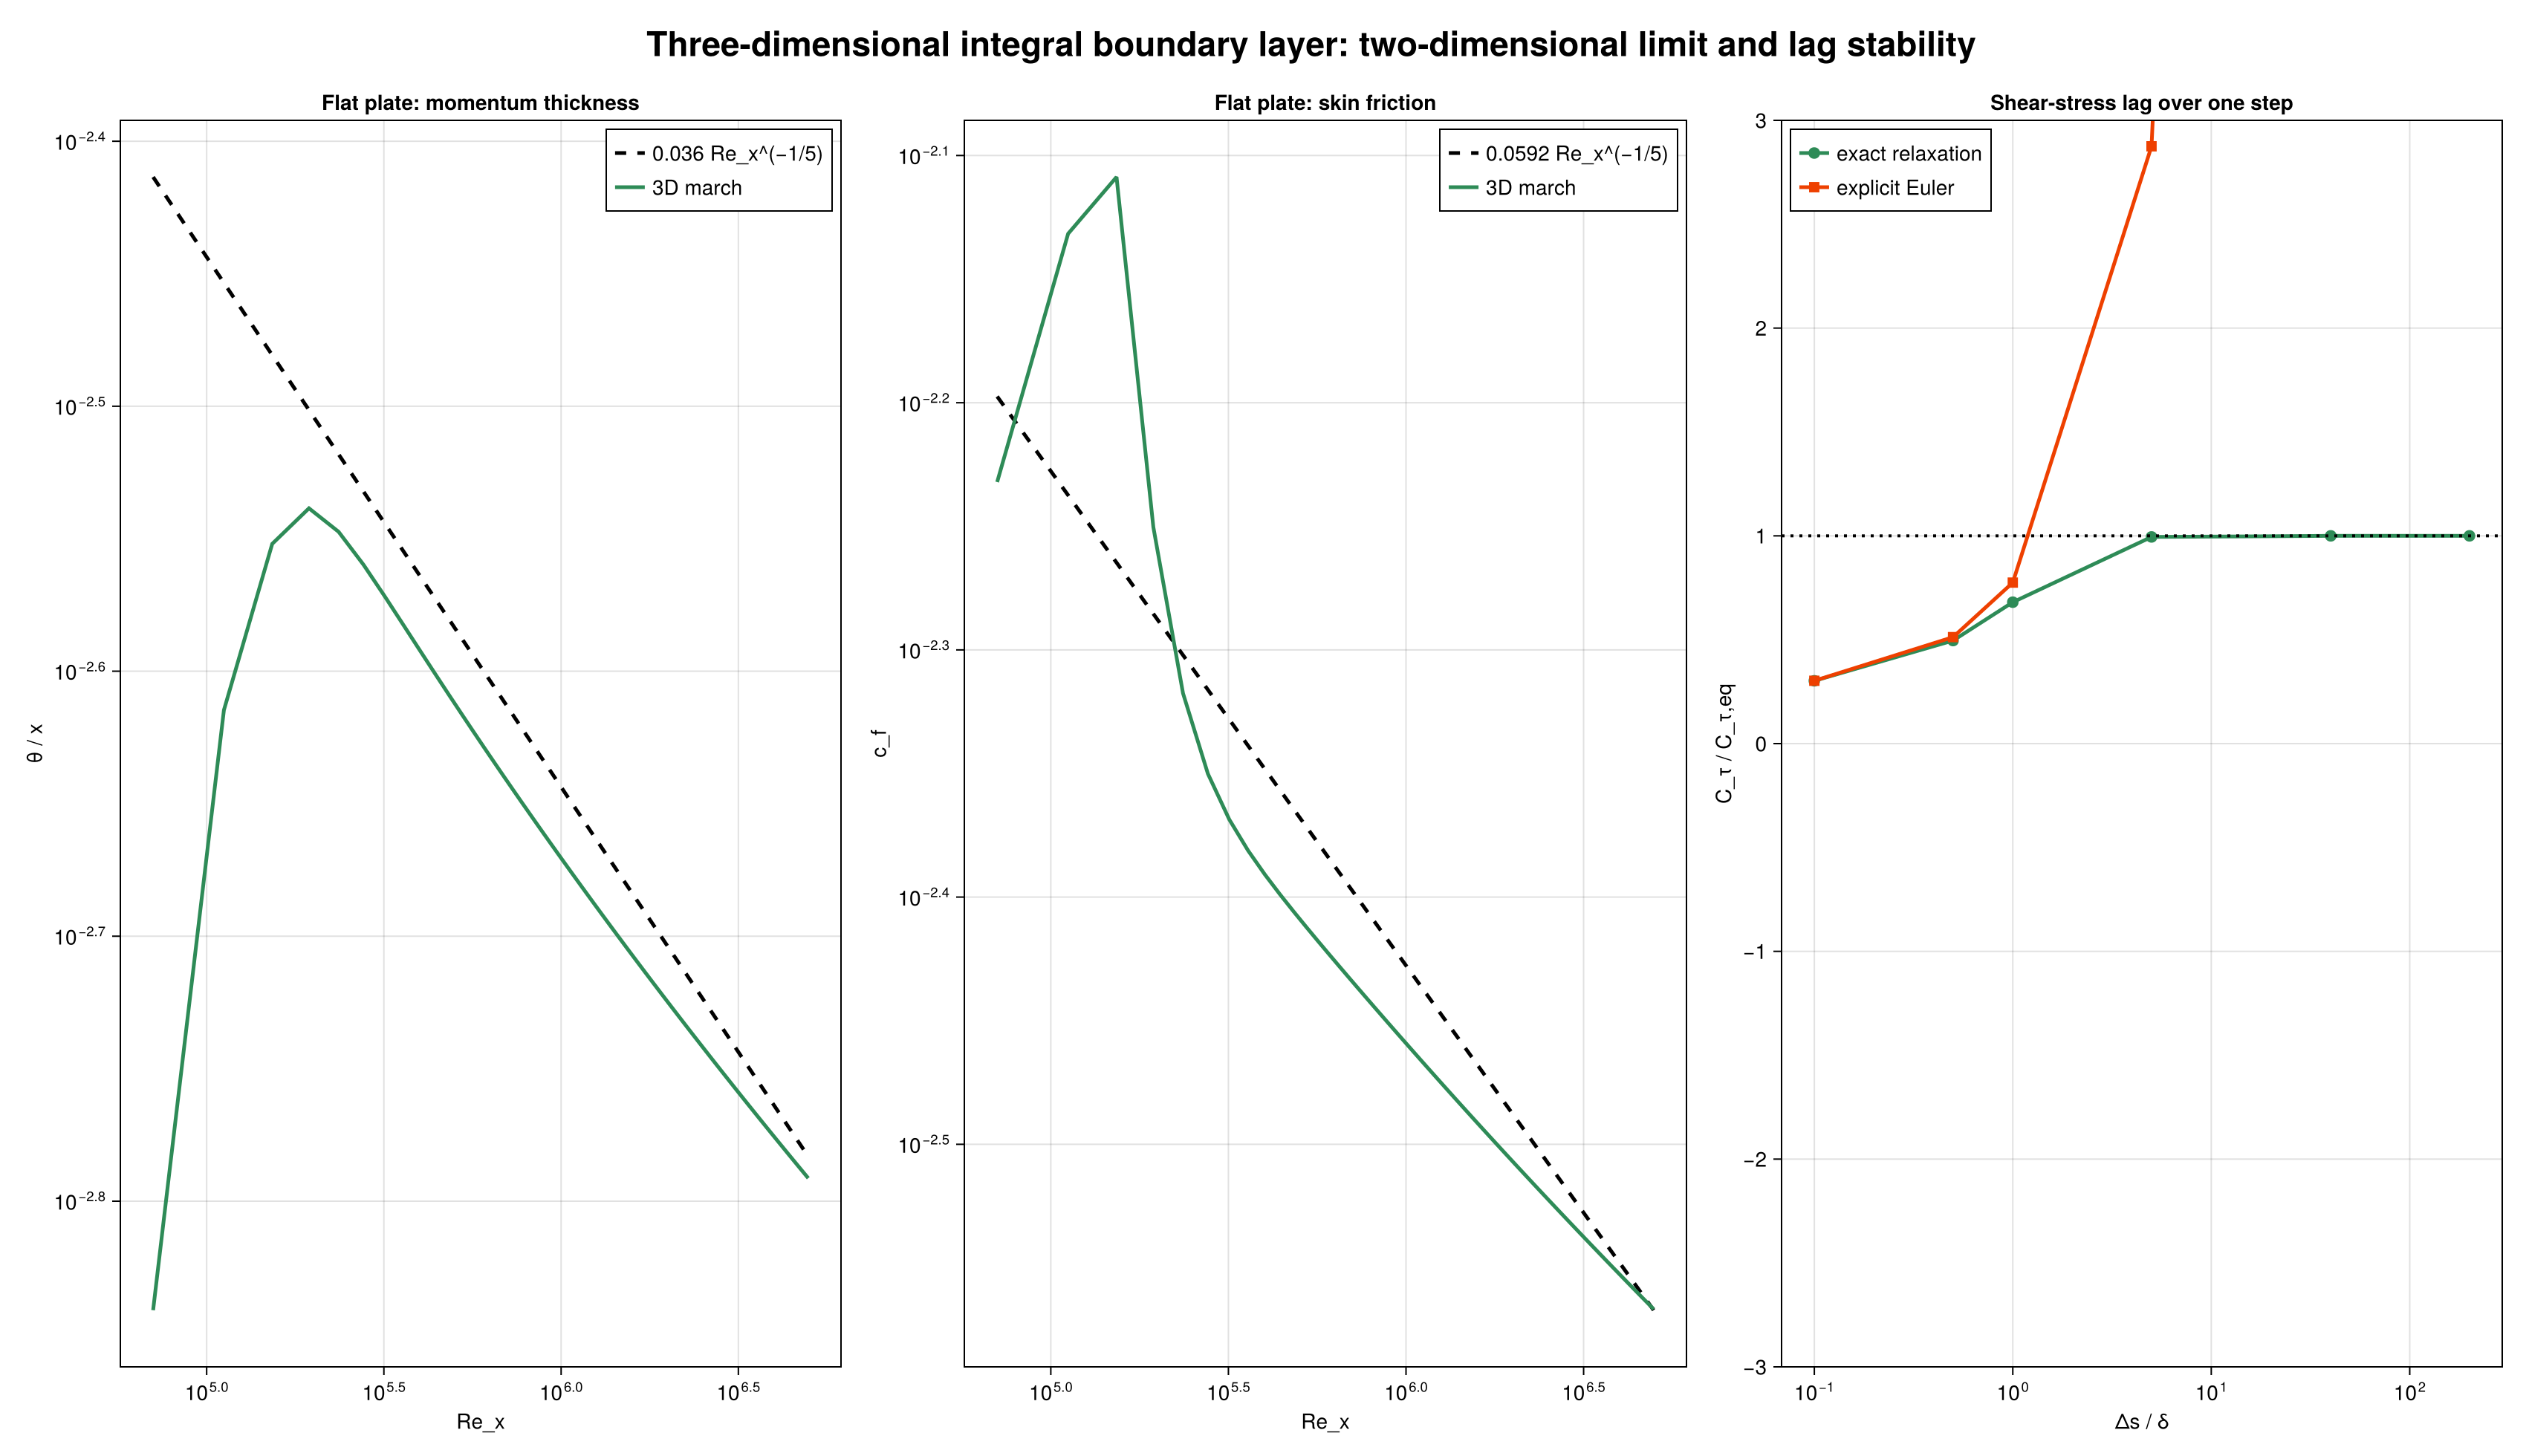

In [7]:
figure = Figure(size = (1700, 980), backgroundcolor = :white)

plate_theta_axis = Axis(figure[1, 1]; title = "Flat plate: momentum thickness",
    xlabel = "Re_x", ylabel = "θ / x", xscale = log10, yscale = log10)
lines!(plate_theta_axis, plate_reynolds, theta_law ./ plate_x; color = :black,
    linestyle = :dash, linewidth = 2.5, label = "0.036 Re_x^(−1/5)")
lines!(plate_theta_axis, plate_reynolds, plate_theta ./ plate_x; color = :seagreen4,
    linewidth = 2.5, label = "3D march")
axislegend(plate_theta_axis; position = :rt)

plate_friction_axis = Axis(figure[1, 2]; title = "Flat plate: skin friction",
    xlabel = "Re_x", ylabel = "c_f", xscale = log10, yscale = log10)
lines!(plate_friction_axis, plate_reynolds, friction_law; color = :black,
    linestyle = :dash, linewidth = 2.5, label = "0.0592 Re_x^(−1/5)")
lines!(plate_friction_axis, plate_reynolds, plate_friction; color = :seagreen4,
    linewidth = 2.5, label = "3D march")
axislegend(plate_friction_axis; position = :rt)

lag_axis = Axis(figure[1, 3]; title = "Shear-stress lag over one step",
    xlabel = "Δs / δ", ylabel = "C_τ / C_τ,eq", xscale = log10)
scatterlines!(lag_axis, step_ratios, exact_relaxation; color = :seagreen4,
    linewidth = 2.5, marker = :circle, markersize = 11, label = "exact relaxation")
scatterlines!(lag_axis, step_ratios, explicit_relaxation; color = :orangered2,
    linewidth = 2.5, marker = :rect, markersize = 11, label = "explicit Euler")
hlines!(lag_axis, [1.0]; color = :black, linestyle = :dot, linewidth = 2)
ylims!(lag_axis, -3, 3)
axislegend(lag_axis; position = :lt)

Label(figure[0, :],
    "Three-dimensional integral boundary layer: two-dimensional limit and lag stability";
    fontsize = 23, font = :bold)
save(joinpath(results_directory, "three_dimensional_verification.png"), figure;
    px_per_unit = 1.5)
figure

## 4.5 Local flow field on the hull

The remaining figures show the inviscid field the boundary layer is driven by,
and the diagnostic that explains the marching failure. All are on the
480-panel double body at zero drift.

The pressure is the steady double-body coefficient
$C_p = 1 - |\boldsymbol u_e|^2/U^2$, which follows from the same surge
potential that supplies the edge velocity.

In [8]:
edge_speed = [norm(@view edge_velocity[panel, :]) for panel in 1:mesh.nfaces]
pressure_coefficient = 1 .- (edge_speed ./ forward_speed) .^ 2

longitudinal_extent = -(-(extrema(mesh.centers[:, 1])...))
visualization_grid = read_gothenburg2010_panel_grid(surface_paths;
    target_shape = (32, 17))
visualization_mesh = visualization_grid.mesh
visualization_surge = solve_rigid_body_potential(visualization_mesh, :surge)
visualization_edge = body_relative_edge_velocity(visualization_mesh, 1.0, 0.0, 0.0;
    surge_gradient = visualization_surge.potential_gradient)
visualization_speed = [norm(@view visualization_edge[panel, :])
                       for panel in 1:visualization_mesh.nfaces]
visualization_pressure = 1 .- visualization_speed .^ 2
visualization_extent = -(-(extrema(visualization_mesh.centers[:, 1])...))
bow_limit = maximum(visualization_mesh.centers[:, 1]) - 0.12 * visualization_extent
stagnation = surface_stagnation_panel(visualization_mesh, visualization_edge;
    panel_mask = visualization_mesh.centers[:, 1] .>= bow_limit)
streamlines = trace_surface_streamlines(visualization_mesh, visualization_edge,
    [first(strip) for strip in visualization_grid.strips];
    step_size = 0.003 * visualization_extent, max_steps = 650, neighbor_count = 10,
    maximum_surface_distance = 0.06 * visualization_extent)

(; panels = visualization_mesh.nfaces,
    minimum_pressure = minimum(visualization_pressure),
    maximum_pressure = maximum(visualization_pressure),
    stagnation_point = stagnation.point)

(panels = 1984, minimum_pressure = -0.3807923568119469, maximum_pressure = 0.9477680780052673, stagnation_point = [0.5244190738296624, -0.0015275739393326151, -0.02868081053071266])

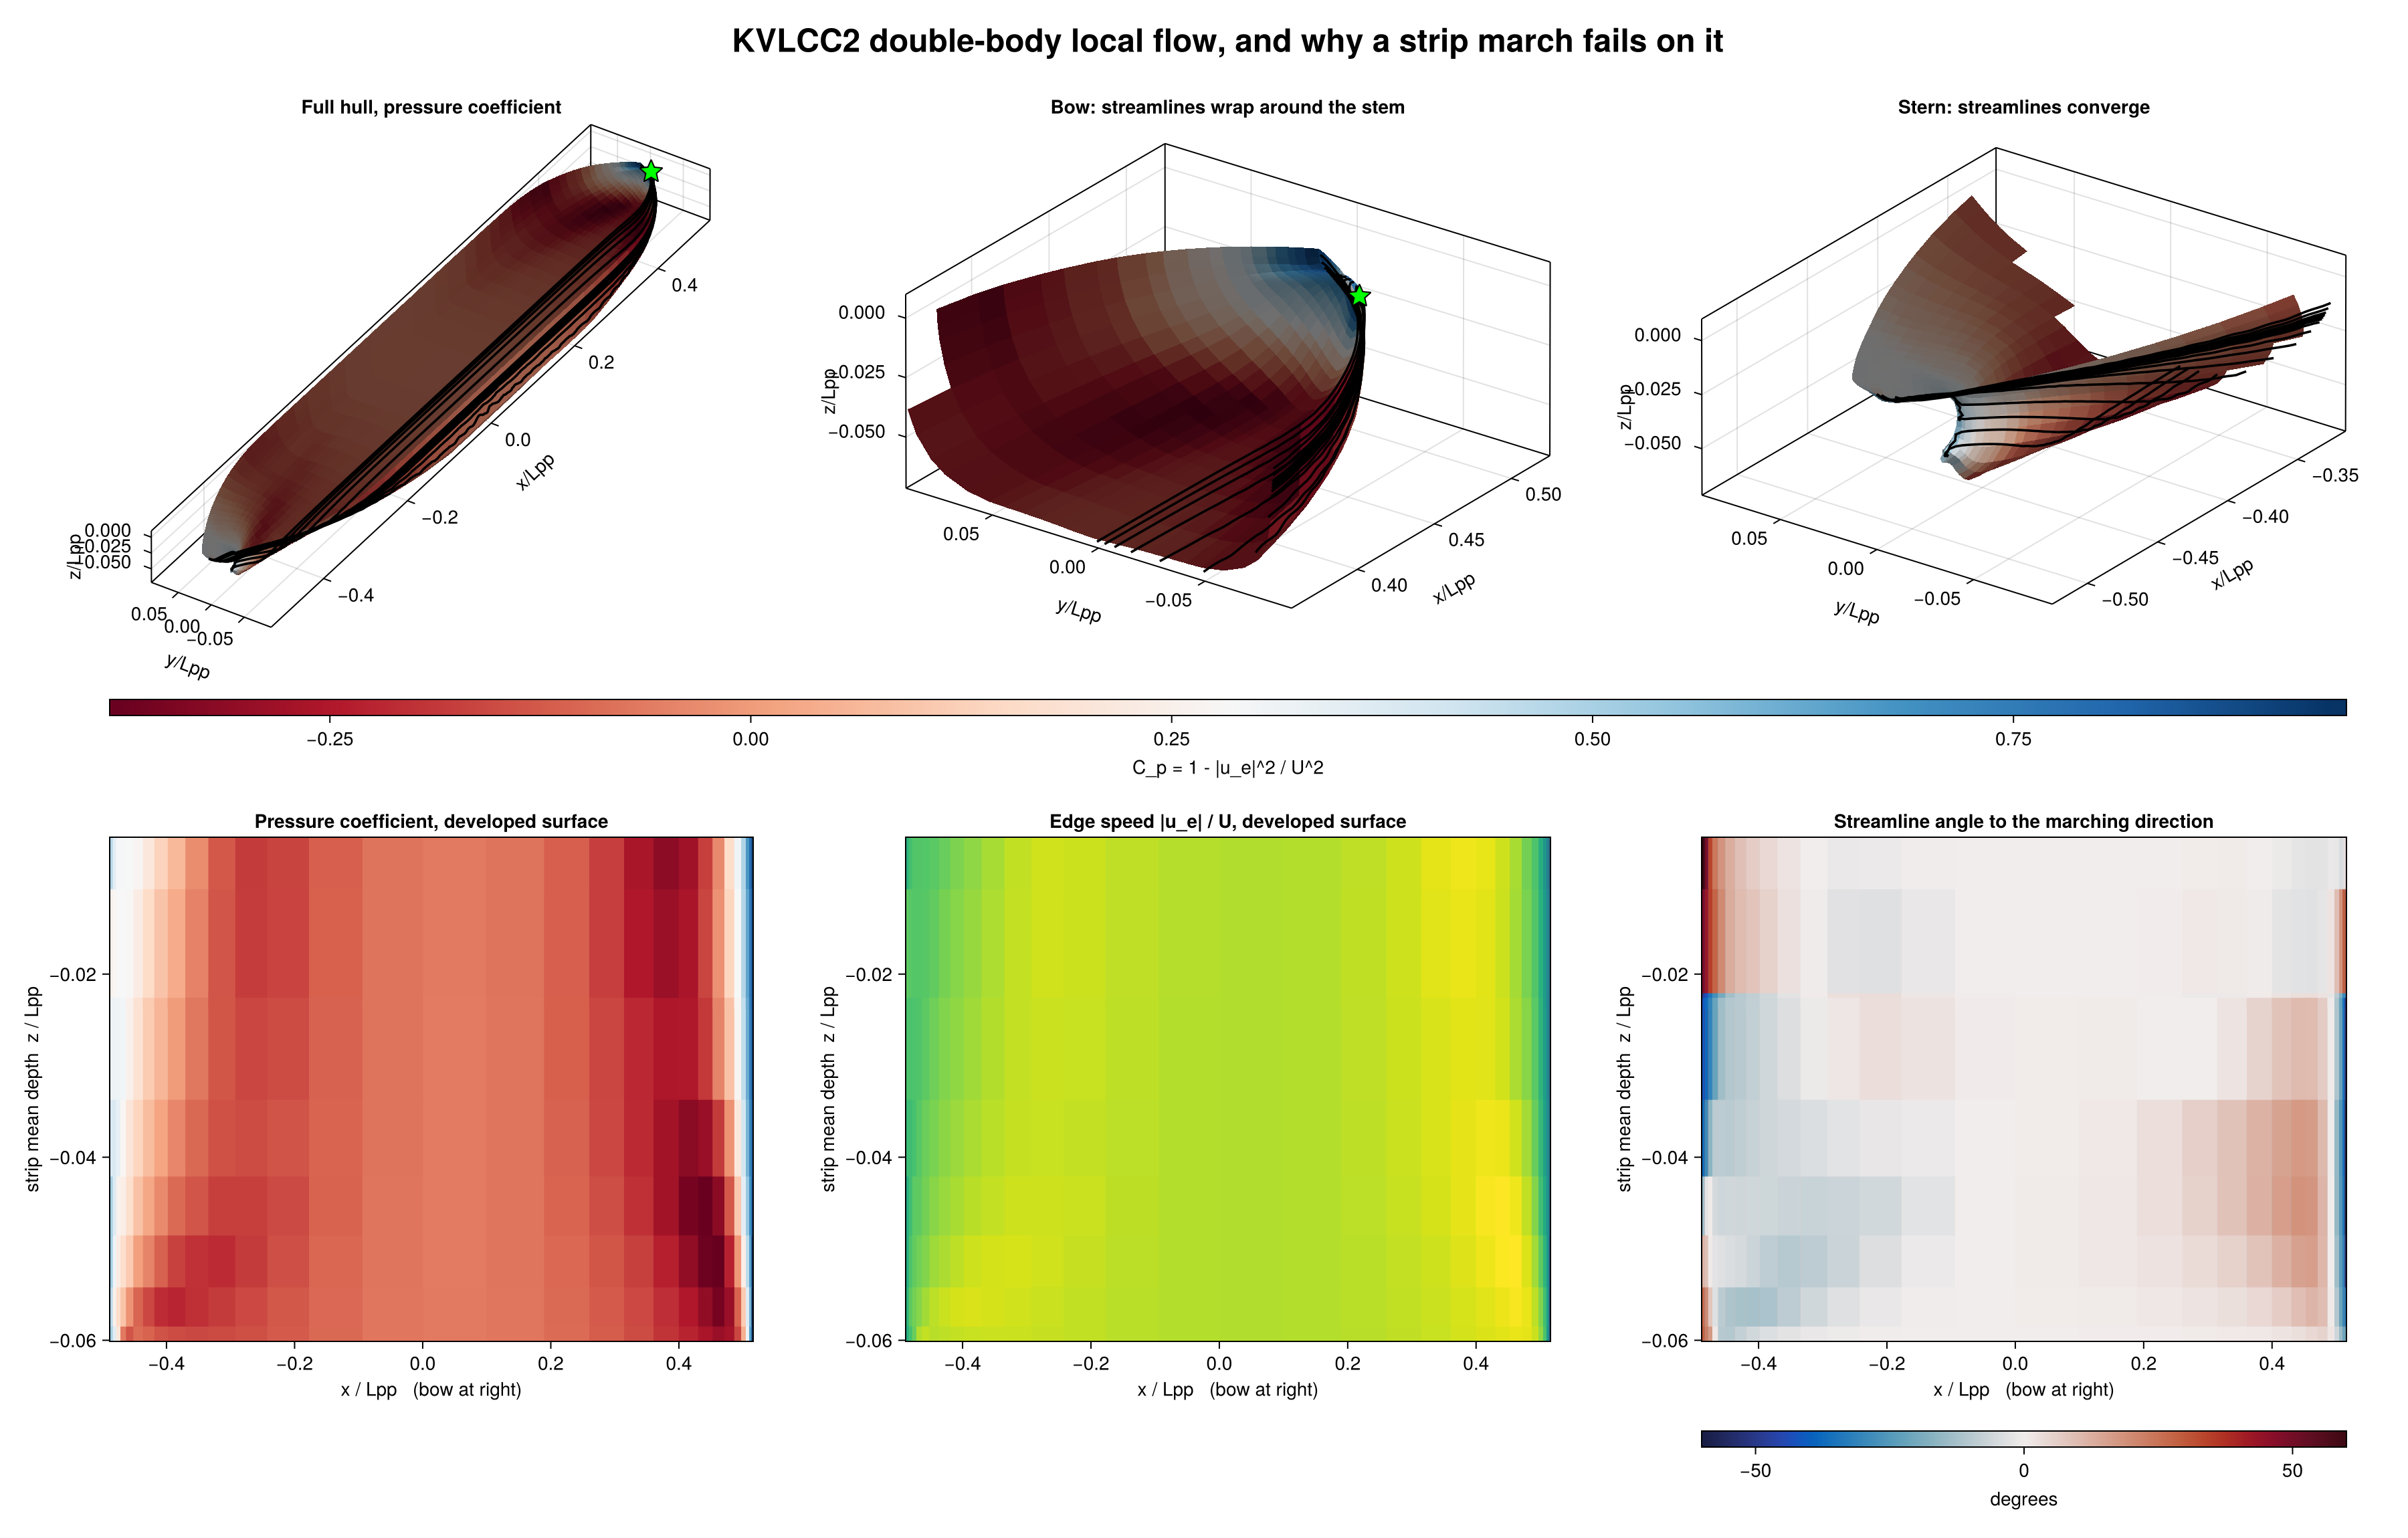

In [9]:
function panel_triangles(mesh, values)
    points = Point3f[]
    faces = NTuple{3, Int}[]
    colors = Float64[]
    for panel in 1:mesh.nfaces
        indices = mesh.faces[panel, :] .+ 1
        base = length(points)
        for index in indices
            push!(points, Point3f(mesh.vertices[index, 1], mesh.vertices[index, 2],
                mesh.vertices[index, 3]))
            push!(colors, values[panel])
        end
        push!(faces, (base + 1, base + 2, base + 3))
        push!(faces, (base + 1, base + 3, base + 4))
    end
    return points, reduce(vcat, [[f[1] f[2] f[3]] for f in faces]), colors
end

surface_points, surface_faces, surface_colors = panel_triangles(visualization_mesh,
    visualization_pressure)
pressure_range = (minimum(visualization_pressure), maximum(visualization_pressure))
x_bounds = extrema(visualization_mesh.vertices[:, 1])
y_bounds = extrema(visualization_mesh.vertices[:, 2])
z_bounds = extrema(visualization_mesh.vertices[:, 3])

# Seed every fourth strip so the streamlines stay readable.
sparse_lines = streamlines[1:2:end]

function add_hull!(axis; x_limits = x_bounds, show_stagnation = false)
    mesh!(axis, surface_points, surface_faces; color = surface_colors,
        colormap = :RdBu, colorrange = pressure_range)
    for line in sparse_lines
        size(line.points, 1) < 2 && continue
        lines!(axis, line.points[:, 1], line.points[:, 2], line.points[:, 3];
            color = :black, linewidth = 1.8)
    end
    if show_stagnation
        scatter!(axis, [stagnation.point[1]], [stagnation.point[2]],
            [stagnation.point[3]]; color = :lime, marker = :star5, markersize = 20,
            strokecolor = :black, strokewidth = 1)
    end
    xlims!(axis, x_limits...)
    ylims!(axis, y_bounds...)
    zlims!(axis, 1.1 * z_bounds[1], 0.01)
    return axis
end

figure = Figure(size = (1800, 1150), backgroundcolor = :white)

full_axis = Axis3(figure[1, 1]; aspect = :data, azimuth = 1.18pi, elevation = 0.20pi,
    xlabel = "x/Lpp", ylabel = "y/Lpp", zlabel = "z/Lpp",
    title = "Full hull, pressure coefficient")
bow_axis = Axis3(figure[1, 2]; aspect = :data, azimuth = 1.20pi, elevation = 0.14pi,
    xlabel = "x/Lpp", ylabel = "y/Lpp", zlabel = "z/Lpp",
    title = "Bow: streamlines wrap around the stem")
stern_axis = Axis3(figure[1, 3]; aspect = :data, azimuth = 1.20pi, elevation = 0.14pi,
    xlabel = "x/Lpp", ylabel = "y/Lpp", zlabel = "z/Lpp",
    title = "Stern: streamlines converge")

add_hull!(full_axis; show_stagnation = true)
add_hull!(bow_axis;
    x_limits = (x_bounds[2] - 0.16 * visualization_extent, x_bounds[2]),
    show_stagnation = true)
add_hull!(stern_axis;
    x_limits = (x_bounds[1], x_bounds[1] + 0.20 * visualization_extent))
Colorbar(figure[2, 1:3]; limits = pressure_range, colormap = :RdBu, vertical = false,
    flipaxis = false, height = 12, label = "C_p = 1 - |u_e|^2 / U^2")

# Developed-surface maps: one row per girth strip at its mean depth, bow right.
strips_ordered = [grid.strips[index] for index in topology.girth_order]
station_count = length(first(strips_ordered))
developed(values) = [values[strips_ordered[strip][station]]
                     for station in 1:station_count, strip in eachindex(strips_ordered)]
station_x = [sum(mesh.centers[strips_ordered[strip][station], 1]
                 for strip in eachindex(strips_ordered)) / length(strips_ordered)
             for station in 1:station_count]
strip_depth = [sum(mesh.centers[panel, 3] for panel in strip) / length(strip)
               for strip in strips_ordered]

pressure_map = developed(pressure_coefficient)
pressure_axis = Axis(figure[3, 1]; title = "Pressure coefficient, developed surface",
    xlabel = "x / Lpp   (bow at right)", ylabel = "strip mean depth  z / Lpp")
heatmap!(pressure_axis, station_x, strip_depth, pressure_map; colormap = :RdBu,
    colorrange = extrema(pressure_coefficient))

speed_map = developed(edge_speed ./ forward_speed)
speed_axis = Axis(figure[3, 2]; title = "Edge speed |u_e| / U, developed surface",
    xlabel = "x / Lpp   (bow at right)", ylabel = "strip mean depth  z / Lpp")
heatmap!(speed_axis, station_x, strip_depth, speed_map; colormap = :viridis,
    colorrange = (0, maximum(speed_map)))

misalignment_map = developed(misalignment)
misalignment_limit = maximum(abs, misalignment)
misalignment_axis = Axis(figure[3, 3];
    title = "Streamline angle to the marching direction",
    xlabel = "x / Lpp   (bow at right)", ylabel = "strip mean depth  z / Lpp")
heatmap!(misalignment_axis, station_x, strip_depth, misalignment_map;
    colormap = :balance, colorrange = (-misalignment_limit, misalignment_limit))
Colorbar(figure[4, 3]; limits = (-misalignment_limit, misalignment_limit),
    colormap = :balance, vertical = false, flipaxis = false, height = 12,
    label = "degrees")

Label(figure[0, :],
    "KVLCC2 double-body local flow, and why a strip march fails on it";
    fontsize = 24, font = :bold)
rowsize!(figure.layout, 2, Relative(0.03))
rowsize!(figure.layout, 4, Relative(0.03))
save(joinpath(results_directory, "three_dimensional_flow_field.png"), figure;
    px_per_unit = 1.5)
figure

The bow view shows the mechanism directly: the streamlines leave the
stagnation point (green star) and wrap around the stem, crossing the girth
lines at a large angle before straightening out along the parallel middle
body. The pressure map shows the corresponding stagnation peak and the
suction over the shoulder.

The right-hand developed map is the diagnosis. The misalignment is confined
to a narrow band at the stem and another at the transom, and is near zero over
the eighty per cent of the hull in between. That band at the stem is where
every strip's march begins.

It is also a direct measure of how much crossflow the quasi-3D model discards
there: it treats a flow at sixty degrees to its marching direction as though
it were aligned with it.

## 4.6 Where this leaves the predictions

Honestly: **not yet improved.** The three-dimensional formulation is
implemented and verified in its two-dimensional limit, but it cannot yet run
on a hull, so the maneuvering derivatives still come from the quasi-3D model
of notebook 2.

What did change in the derivatives is smaller and separate. Following Wang et
al., the viscous correction is now integrated over the **attached** region
only — downstream of separation the attached closure is invalid, so any
pressure it predicts there carries no information. The shear contribution
already respected this because the closure zeroes the wall stress past
separation; the displacement-pressure integral did not.

In [10]:
inviscid = solve_potential_flow_maneuvering(mesh, forward_speed; rho = WATER_DENSITY)
correction = viscous_maneuvering_correction(grid, surge, inviscid, forward_speed,
    kinematic_viscosity; rho = WATER_DENSITY)
corrected = apply_viscous_correction(inviscid.derivatives, correction)

println("whole-hull inviscid      : ", prime(inviscid.derivatives))
println("+ Head, attached only    : ", prime(corrected))
println("Schmitz truncated        : ", cut_rows[2].derivatives)
println("MMG reference            : ", reference)

whole-hull inviscid      : (Y_v = 0.0011105103765132053, Y_r = -0.004781427088453, N_v = -0.01483919416800598, N_r = -0.0003204303758231644)
+ Head, attached only    : (Y_v = -0.0024364082463614123, Y_r = -0.0036769212054909017, N_v = -0.01341472713481863, N_r = -0.0009927872077918891)
Schmitz truncated        : (Y_v = -0.018793792444379235, Y_r = -0.0012994264374578902, N_v = -0.007784916325640364, N_r = -0.00207799219082891)
MMG reference            : (Y_v = -0.020475, Y_r = 0.005395, N_v = -0.008905, N_r = -0.003185)


## 4.7 Summary

| Item | Status |
|---|---|
| Momentum-loss tensor and crossflow closure | Implemented; collapses exactly to 2D at $\beta_w=0$ |
| Two momentum + kinetic energy equations | Implemented in local Cartesian form |
| Shear-stress lag | Implemented, integrated exactly; explicit Euler is unstable here |
| Flat-plate verification | Passes: $\theta$ within 2 %, $c_f$ within 0.1 % |
| Full hull | **Fails.** Strip marching is ill-posed where streamlines cross the strips |
| Global upwind surface solve | Not implemented — the next piece of work |
| Attached-only viscous integration | Implemented, per Wang et al. |
| Schmitz vs separation cut | Compared; they are unrelated, and that is informative |

The honest summary is that the physics content is in place and verified, and
the discretisation is not yet the right one for this geometry. Swapping the
march for a globally coupled upwind solve is a contained, well-specified piece
of work, and it is the only thing standing between this formulation and a
crossflow prediction on a real hull.